# prophet model from facebook to be used in time series forecasting

In [15]:
# import laibraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import warnings
warnings.filterwarnings("ignore")

In [33]:
# import the dataset
df = pd.read_csv("resourses/DailyDelhiClimateTrain.csv", parse_dates=True)
df.head()

,date,meantemp,humidity,wind_speed,meanpressure
0,2013-01-01,10.000000,84.500000,0.000000,1015.666667
1,2013-01-02,7.400000,92.000000,2.980000,1017.800000
2,2013-01-03,7.166667,87.000000,4.633333,1018.666667
3,2013-01-04,8.666667,71.333333,1.233333,1017.166667
4,2013-01-05,6.000000,86.833333,3.700000,1016.500000


In [17]:
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 1462 entries, 2013-01-01 to 2017-01-01
Data columns (total 4 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   meantemp      1462 non-null   float64
 1   humidity      1462 non-null   float64
 2   wind_speed    1462 non-null   float64
 3   meanpressure  1462 non-null   float64
dtypes: float64(4)
memory usage: 57.1 KB


<Axes: xlabel='date', ylabel='meantemp'>

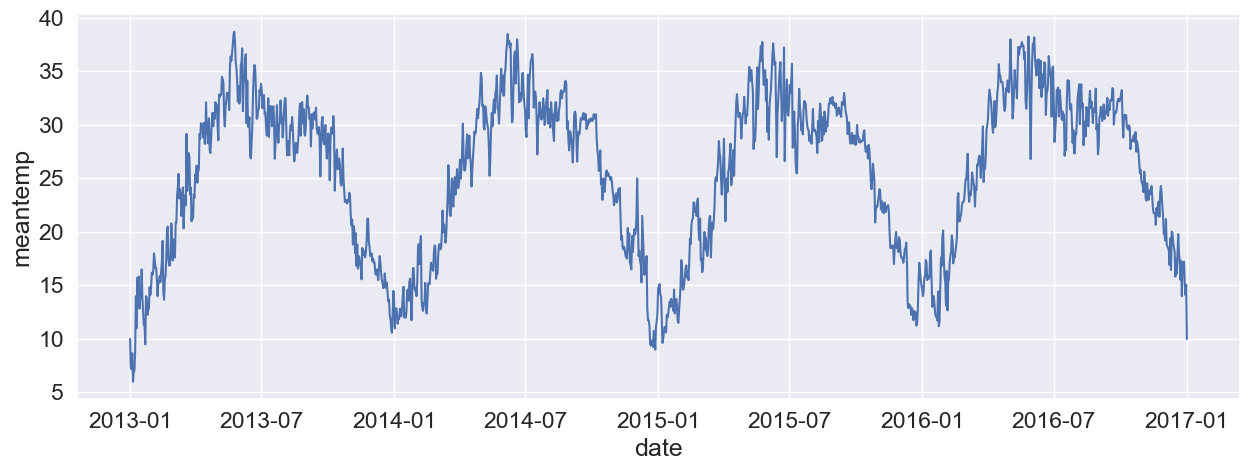

In [18]:
# draw a line  plot 
sns.set(rc={'figure.figsize':(15,5)}, font_scale=1.5, style="darkgrid")
sns.lineplot(data=df, x="date", y="meantemp")

In [19]:
# draw a line plot in plotly
fig = px.scatter(
    df, 
    x='meantemp',
    y='humidity', 
    title='Mean Temprature',
    trendline="ols", 
    trendline_color_override="red"  # <-- Removed the 's' at the 
)
fig.show()

In [20]:
from scipy.stats import pearsonr

correlation, _ = pearsonr(df['meantemp'], df['humidity'])
print(f"Correlation between meantemp and humidity: %.3f"  % correlation)

Correlation between meantemp and humidity: -0.572


<Axes: >

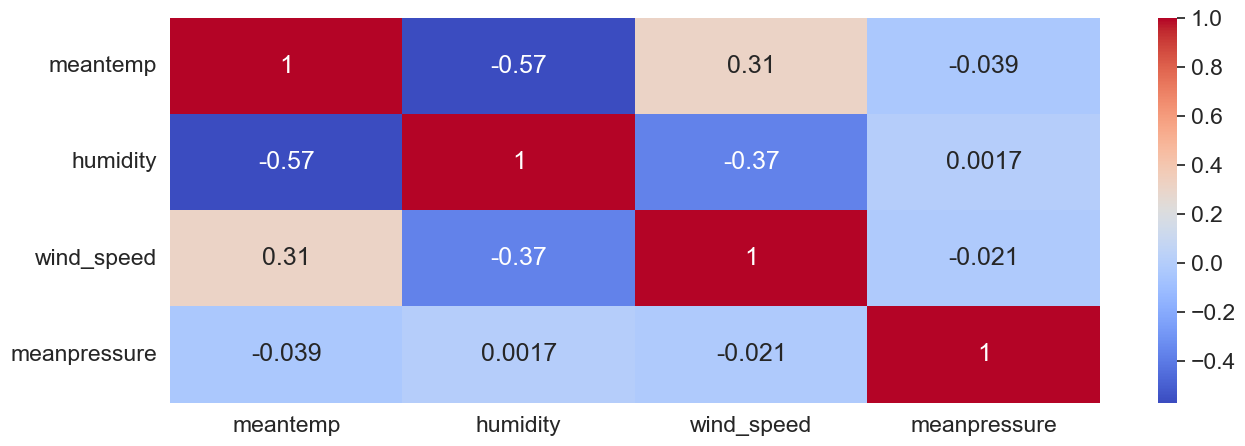

In [21]:
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')

In [22]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
df_scaled = pd.DataFrame(scaler.fit_transform(df), columns=df.columns, index=df.index)
df_scaled.describe()

,meantemp,humidity,wind_speed,meanpressure
count,1.462000e+03,1.462000e+03,1.462000e+03,1.462000e+03
mean,-1.458022e-17,1.968330e-16,-1.944029e-16,-5.880689e-16
std,1.000342e+00,1.000342e+00,1.000342e+00,1.000342e+00
min,-2.654044e+00,-2.824109e+00,-1.491699e+00,-5.628829e+00
25%,-9.037230e-01,-6.201833e-01,-7.296443e-01,-5.286224e-02
50%,3.020541e-01,1.105528e-01,-1.273107e-01,-1.410365e-02
75%,7.909894e-01,6.828386e-01,5.342114e-01,2.131517e-02
max,1.799551e+00,2.340044e+00,7.766988e+00,3.701076e+01


<Axes: >

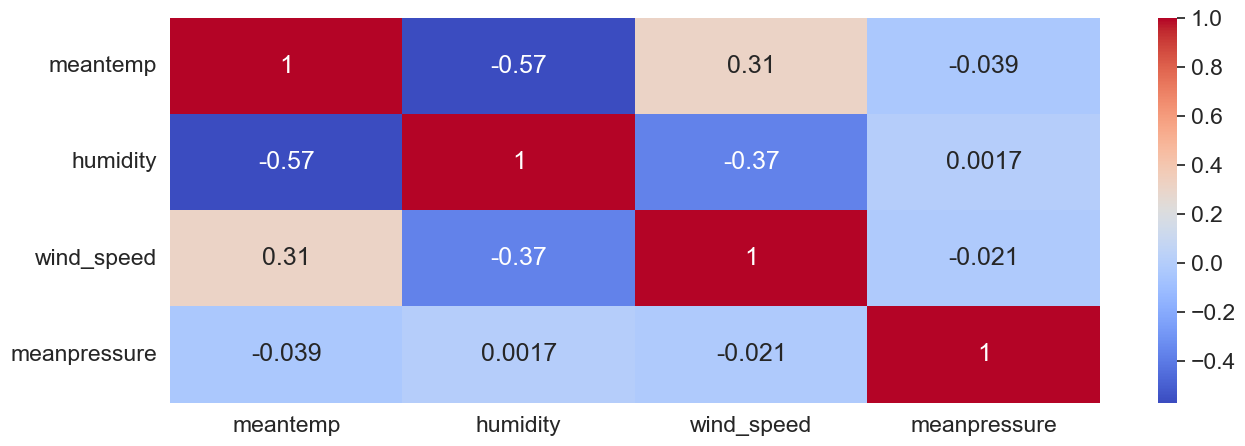

In [23]:
# make a heatmap on scaled data
sns.heatmap(df_scaled.corr(), cmap='coolwarm', annot=True)

In [26]:
fig = px.line(df, x=df.index, y='meanpressure', title='Mean Pressure')
fig.show()

In [25]:
df.loc['2016-03-28', 'meanpressure'] = np.nan
df['meanpressure'] = df['meanpressure'].interpolate(method='time')
df.loc['2016-03-28']

meantemp          25.933333
humidity          52.800000
wind_speed         6.546667
meanpressure    1012.062500
Name: 2016-03-28 00:00:00, dtype: float64

In [27]:
# add two columns in the dataset for month and year
df_scaled['month'] = df_scaled.index.month
df_scaled['year'] = df_scaled.index.year
df_scaled.head()

,meantemp,humidity,wind_speed,meanpressure,month,year
date,,,,,,
2013-01-01,-2.109500,1.415439,-1.491699,0.025321,1,2013
2013-01-02,-2.463454,1.862828,-0.838196,0.037162,1,2013
2013-01-03,-2.495219,1.564569,-0.475626,0.041972,1,2013
2013-01-04,-2.291015,0.630022,-1.221233,0.033647,1,2013
2013-01-05,-2.654044,1.554627,-0.680303,0.029946,1,2013


TypeError: _AxesBase.set_xlim() takes from 1 to 3 positional arguments but 4 were given

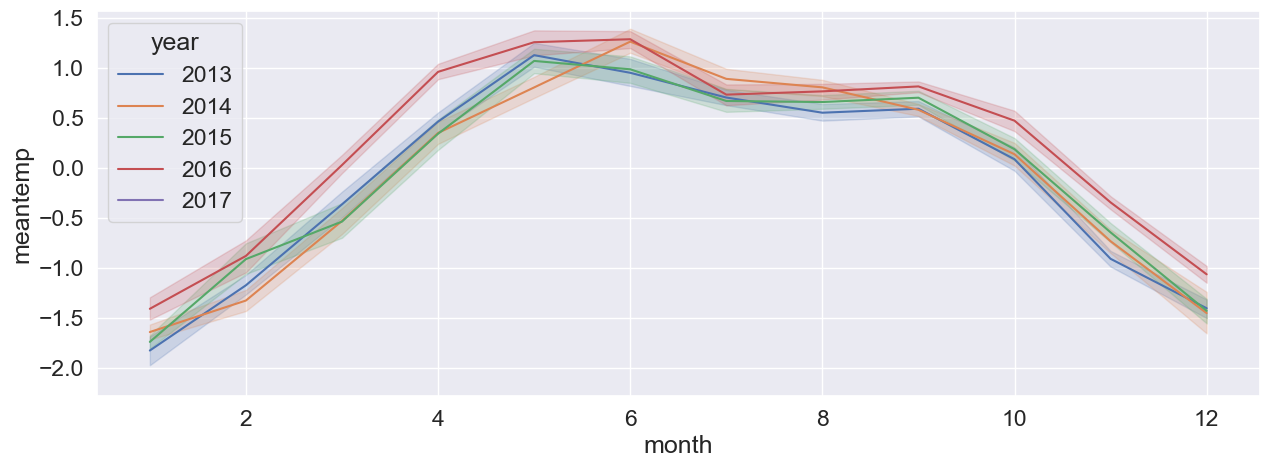

In [29]:
sns.lineplot(data=df_scaled, x='month', y='meantemp', hue='year', palette='deep')
plt.xlim(1, 12, 1)

lets use the prophet model from python

In [35]:
df.head()

# rename the columns to ds and y
df = df.rename(columns={"date": "ds", "meantemp": "y"})
df.head()

,ds,y,humidity,wind_speed,meanpressure
0,2013-01-01,10.000000,84.500000,0.000000,1015.666667
1,2013-01-02,7.400000,92.000000,2.980000,1017.800000
2,2013-01-03,7.166667,87.000000,4.633333,1018.666667
3,2013-01-04,8.666667,71.333333,1.233333,1017.166667
4,2013-01-05,6.000000,86.833333,3.700000,1016.500000


In [38]:
from prophet import Prophet
from prophet.plot import plot_plotly, plot_components_plotly

# create a prophet model
model = Prophet()

# fit the model to the data
model.fit(df)

# create a future dataframe
future = model.make_future_dataframe(periods=365)

# predict the future
forecast = model.predict(future)

# plot the forecast
plot_plotly(model, forecast)


22:10:54 - cmdstanpy - INFO - Chain [1] start processing
22:10:55 - cmdstanpy - INFO - Chain [1] done processing
